In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

import os
os.environ["VXM_BACKEND"] = "pytorch"
device = torch.device("cuda", torch.cuda.current_device())

# Load data (rolling shutter)

In [2]:
from skimage.io import imread

path = "Simulation/Data3"

n_acquisitions = 100
n_frames = 140
shape = (n_frames,11,100)

def read_simulation_rolling_shutter(path):
    data = np.zeros((n_acquisitions,)+shape,dtype=np.float32)
    for f in range(n_acquisitions):
        file = os.path.join(path, f"volume_{f+1:03d}.tif")
        data[f] = imread(file).astype(np.float32)
    return torch.tensor(data,dtype=torch.float32,device=device)
data = read_simulation_rolling_shutter(os.path.join(path,"VolumeOverTime"))

# Read from the Log.txt file. These correspond to the acquisition time.
# In simulation, they are random, but in real data, they should be increasing
frameStarts = torch.tensor([
    853,784,882,1006,406,293,739,355,193,927,92,360,760,836,46,276,812,644,33,25,649,352,71,923,940,633,311,9,350,721,946,298,989,969,583,655,311,478,380,26,146,676,131,750,874,547,3,569,892,374,512,478,380,155,726,324,894,503,930,270,569,870,149,897,555,36,488,8,129,510,224,915,88,817,500,266,988,429,294,379,755,715,292,445,614,350,402,449,823,435,397,23,472,690,587,957,363,597,14,303
],device=device)

# Clean up, some simulations appear corrupt
# idxs = torch.tensor([0,1,2,4,5,6,8,11,13,14,16])
idxs = torch.argwhere(data[:,:,5,:].amin(dim=(1,2))>0)[:,0]
data = data[idxs]
frameStarts = frameStarts[idxs]
n_acquisitions = data.shape[0]

# Simulated filaments info
n_filaments = 2
nSegmL = 2
nNodes = 40
attachmentPoints = torch.tensor([
    [50, 5.5, 20],
    [42, 3.5, 20],
],dtype=torch.float32,device=device)

assert attachmentPoints.shape[0] == n_filaments

# Filament generation

In [ ]:
# Generated with copilot

# Polymer model
def get_filaments(frame, flexRig, nPeriod, frameStart, phaseOffset, basePosition):
    node_idx = torch.arange(
        1, nNodes,
        device=device,
        dtype=flexRig.dtype
    )

    base_phase = node_idx * torch.pi / nNodes
    phase = (
        base_phase[None, :]
        + 2 * torch.pi * (frame + frameStart) / nPeriod[:, None]
    ) + phaseOffset[:,None]

    dAngle = flexRig[:, None] * torch.sin(phase)
    currAngle = torch.cumsum(dAngle, dim=1)

    dx = nSegmL * torch.cos(currAngle)
    dy = nSegmL * torch.sin(currAngle)

    points = torch.empty(
        (n_filaments, nNodes, 3),
        device=device,
        dtype=flexRig.dtype
    )

    # first node
    points[:, 0, :] = basePosition
    # x-coordinate (axis 2 in your original code)
    points[:, 1:, 2] = (
        basePosition[:, 2:3]
        + torch.cumsum(dx, dim=1)
    )
    # y-coordinate (axis 0 in your original code)
    points[:, 1:, 0] = (
        basePosition[:, 0:1]
        + torch.cumsum(dy, dim=1)
    )
    # z-coordinate remains fixed
    points[:, :, 1] = basePosition[:, 1:2]

    return points

In [ ]:
# Generated with copilot

# Gaussian splatting
sigma=2
inv_two_sigma2 = 1.0 / (2*sigma**2)
# Define a 3x3 covariance matrix
cov = torch.tensor([
    [sigma**2, 0.0,      0.0     ],
    [0.0,      sigma**2, 0.0     ],
    [0.0,      0.0,      sigma**2]
], dtype=torch.float32, device=device)
det = torch.linalg.det(cov)
norm_const = 1.0 / (((2.0 * torch.pi) ** 1.5) * torch.sqrt(det))

D, H, W = data.shape[1:]#(140,11,100)
xgrid = (torch.arange(W, device=device) + 0.5).view(1, 1, 1, W)
ygrid = (torch.arange(H, device=device) + 0.5).view(1, 1, H, 1)
zgrid = (torch.arange(D, device=device) + 0.5).view(1, D, 1, 1)

def splat(points):
    px = points[:, 0][:, None, None, None]
    py = points[:, 1][:, None, None, None]
    pz = points[:, 2][:, None, None, None]

    exponent = -(
        (xgrid - px)**2 +
        (ygrid - py)**2 +
        (zgrid - pz)**2
    ) * inv_two_sigma2

    gaussians = norm_const * torch.exp(exponent)

    final_volume = gaussians.sum(dim=0)

    # FIXME: this hacked from the ImageJ macro and I'm not sure if it's correct
    return n_filaments*final_volume * (600 / 0.04) + n_filaments*100

In [5]:
def simulate_volume(frame, flexRig, nPeriod, frameStart, phaseOffset, basePosition):
    return splat(
        get_filaments(frame, flexRig, nPeriod, frameStart, phaseOffset, basePosition).view(-1,3)
    )

# Forward model

In [ ]:
# Either used with deskewed data or needs to be replaced with 60deg skewed forward model
def forward_model(image, frame):
    return image[frame]

# Optimization

In [ ]:
from tqdm import tqdm

# torch.manual_seed(64)
flexRig_raw = torch.zeros(n_filaments,dtype=torch.float32,device=device)
nPeriod_raw = torch.zeros(n_filaments,dtype=torch.float32,device=device)
phaseOffset_raw = torch.zeros(n_filaments,dtype=torch.float32,device=device)

# Constraints
flexRigRange = [0.03, 0.06]
nPeriodRange = [16, 64]

# Initialize the optimizer
flexRig_raw.requires_grad=True
nPeriod_raw.requires_grad=True
phaseOffset_raw.requires_grad=True
optimizer = torch.optim.NAdam([
    {'params': [nPeriod_raw],     'lr': 0.1e-1},
    {'params': [flexRig_raw],     'lr': 0.1e-1},
    {'params': [phaseOffset_raw], 'lr': 0.1e-1},
])
optimizer.zero_grad()

n_iterations = 500000
batch_size = 300
loss = 0.0

hist_params=torch.zeros((n_iterations,n_filaments,3),device=device)

iterations_tqdm = tqdm(range(n_iterations))
for i in iterations_tqdm:
    # Get frame and acquistion
    # TODO: Could probably be done in a smarter way
    frame = torch.randint(0, n_frames, (1,))[0]
    acquisition = torch.randint(0, n_acquisitions, (1,))[0]

    # Transform parameters
    flexRig = flexRigRange[0] + (flexRigRange[1] - flexRigRange[0]) * torch.sigmoid(flexRig_raw)
    nPeriod = nPeriodRange[0] + (nPeriodRange[1] - nPeriodRange[0]) * torch.sigmoid(nPeriod_raw)
    phaseOffset = torch.pi*torch.tanh(phaseOffset_raw)
    
    # Generate filaments based on parameters
    simulated_volume = simulate_volume(
        frame,
        flexRig,
        nPeriod,
        frameStarts[acquisition],
        phaseOffset,
        attachmentPoints,
    )

    # Data consistency
    data_sim = forward_model(simulated_volume, frame)
    data_obs = data[acquisition,frame]
    loss += torch.nn.functional.mse_loss(data_sim, data_obs)

    if (i+1)%batch_size==0:
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        loss = 0.0

        iterations_tqdm.set_postfix({
            "flexRig":     f"{flexRig.detach().cpu().numpy()}",
            "nPeriod":     f"{nPeriod.detach().cpu().numpy()}",
            "phaseOffset": f"{phaseOffset.detach().cpu().numpy()}"
        })
    
    hist_params[i,:,0]=flexRig.detach()
    hist_params[i,:,1]=nPeriod.detach()
    hist_params[i,:,2]=phaseOffset.detach()

flexRig = flexRig.detach()
nPeriod = nPeriod.detach()
phaseOffset = phaseOffset.detach()

100%|██████████| 500000/500000 [27:32<00:00, 302.59it/s, flexRig=[0.03835514 0.04317332], nPeriod=[35.827507 40.718742], phaseOffset=[0.84788316 1.4536163 ]] 


# Results

In [8]:
print(flexRig.cpu().numpy())
print(nPeriod.cpu().numpy())
print(phaseOffset.cpu().numpy())

[0.03838605 0.04315654]
[35.77809  40.826645]
[0.8691273 1.4275303]


Text(0.5, 1.0, 'phaseOffset')

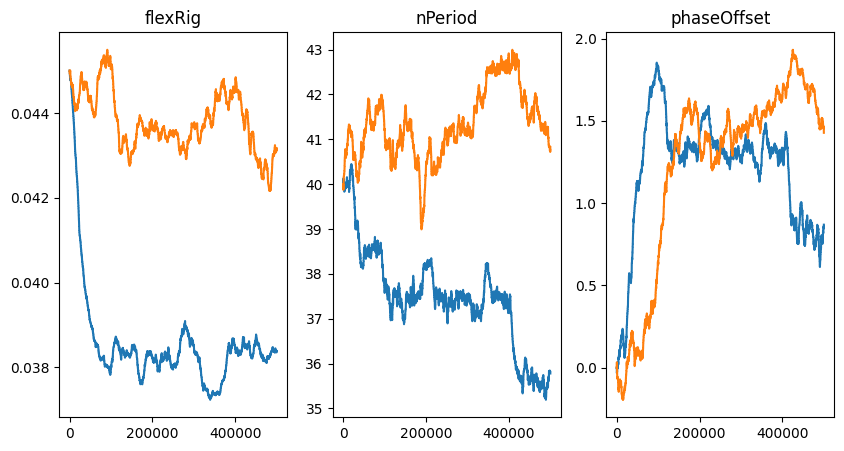

In [9]:
_,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(10,5))
ax1.plot(hist_params[:,:,0].cpu())
ax1.set_title("flexRig")
ax2.plot(hist_params[:,:,1].cpu())
ax2.set_title("nPeriod")
ax3.plot(hist_params[:,:,2].cpu())
ax3.set_title("phaseOffset")

In [10]:
acquisition_result = 0

In [11]:
estimated = torch.zeros((n_frames,)+shape,dtype=torch.float32,device=device)
for f in tqdm(range(n_frames)):
    estimated[f] = simulate_volume(
        f,
        flexRig,
        nPeriod,
        frameStarts[acquisition_result],
        phaseOffset,
        attachmentPoints,
    )

100%|██████████| 140/140 [00:00<00:00, 783.72it/s]


In [12]:
gt = imread(os.path.join(path, f"gt.tif")).astype(np.float32)[frameStarts[acquisition_result]:frameStarts[acquisition_result]+n_frames]

In [13]:
data_estimated = torch.zeros_like(data[acquisition_result])
for f in range(n_frames):
    data_estimated[f] = forward_model(estimated[f],frame=f)

Text(0.5, 1.0, 'estimated')

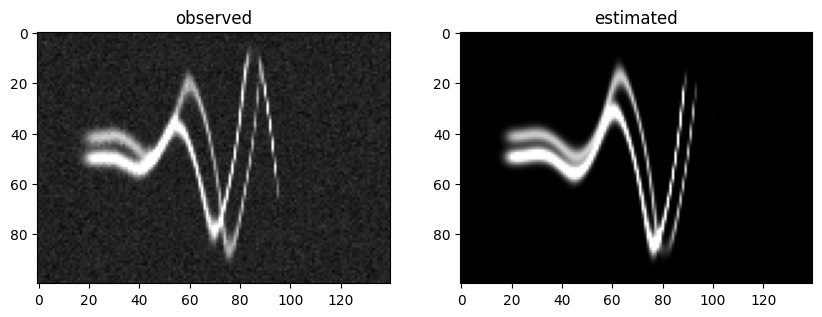

In [14]:
_,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.imshow(data[acquisition_result,:,5,:].cpu().T,cmap='gray',vmax=650)
ax1.set_title("observed")
ax2.imshow(data_estimated[:,5,:].cpu().T,cmap='gray',vmax=650)
ax2.set_title("estimated")